In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset (using the actual filename provided)
df = pd.read_csv('WebTraffic 1.csv')

# Preprocessing: Convert 'date' to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Aggregate data by date to analyze overall trends
daily_traffic = df.groupby('date').agg({
    'visits': 'sum',
    'unique_visitors': 'sum',
    'bounce_rate': 'mean'
}).reset_index()

print("Data successfully loaded and aggregated.")
display(daily_traffic.head())

FileNotFoundError: [Errno 2] No such file or directory: 'WebTraffic 1.csv'

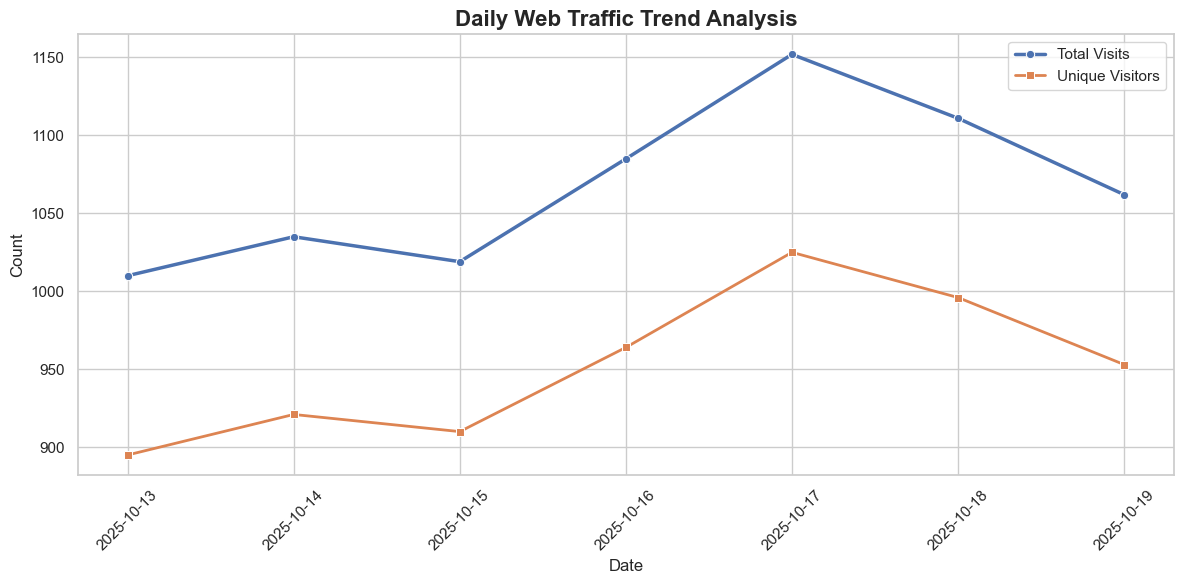

In [ ]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plotting Visits and Unique Visitors
sns.lineplot(data=daily_traffic, x='date', y='visits', marker='o', label='Total Visits', linewidth=2.5)
sns.lineplot(data=daily_traffic, x='date', y='unique_visitors', marker='s', label='Unique Visitors', linewidth=2)

# Formatting for presentation
plt.title('Daily Web Traffic Trend Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(frameon=True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save for PowerPoint
plt.savefig('traffic_trend_static.png', dpi=300)
plt.show()

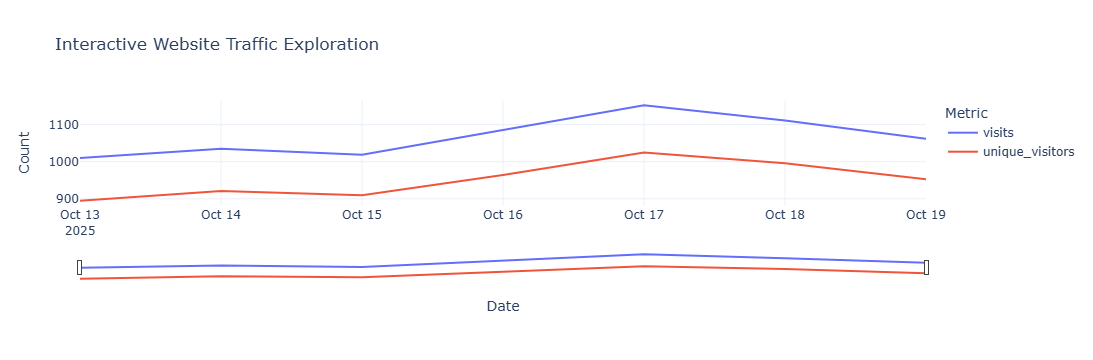

In [ ]:
# Create interactive line chart
fig = px.line(daily_traffic, x='date', y=['visits', 'unique_visitors'],
              title='Interactive Website Traffic Exploration',
              labels={'value': 'Count', 'date': 'Date', 'variable': 'Metric'},
              template='plotly_white')

# Add range slider for better interaction
fig.update_xaxes(rangeslider_visible=True)

# Export as HTML
fig.write_html("traffic_report_interactive.html")
fig.show()

In [ ]:
!pip install fpdf

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40770 sha256=63103f562be88ee4ef21302248bf91e4186c307c552c7016a21ffd91fc0fbea0
  Stored in directory: c:\users\capaciti-jhb\appdata\local\pip\cache\wheels\aa\da\11\a3189f34ddc13c26a2d0f329eac46b728c7f31c39e4dc26243
Successfully built fpdf


In [ ]:
from fpdf import FPDF
class PDFReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Automated Web Traffic Summary', 0, 1, 'C')
        self.ln(10)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')

# Initialize PDF
pdf = PDFReport()
pdf.add_page()
pdf.set_font("Arial", size=12)

# Add Summary Stats Section
pdf.cell(0, 10, "1. Executive Summary", ln=True)
pdf.set_font("Arial", size=10)
avg_visits = round(daily_traffic['visits'].mean(), 2)
max_visits = daily_traffic['visits'].max()
pdf.multi_cell(0, 8, f"Average Daily Visits: {avg_visits}\nPeak Daily Visits: {max_visits}")
pdf.ln(5)

# Add the Trend Plot Image
pdf.cell(0, 10, "2. Traffic Trends Visualization", ln=True)
pdf.image('traffic_trend_static.png', x=10, w=190)

# Save the final automated report
pdf.output("WebTraffic_Automated_Report.pdf")
print("Reports generated successfully: 'traffic_report_interactive.html' and 'WebTraffic_Automated_Report.pdf'")

Reports generated successfully: 'traffic_report_interactive.html' and 'WebTraffic_Automated_Report.pdf'


In [ ]:
import os

# Define your computer's download folder path
# For Windows, it usually looks like this (replace 'YourName'):
download_folder = r'C:\Users\CAPACITI-JHB\Downloads'

# Join the folder path with the filename
pdf_path = os.path.join(download_folder, 'Automated_Traffic_Report.pdf')
html_path = os.path.join(download_folder, 'Automated_Traffic_Report.html')

# When you output the files, use these paths:
pdf.output(pdf_path)
fig.write_html(html_path)

print(f"Files have been sent directly to: {download_folder}")

Files have been sent directly to: C:\Users\CAPACITI-JHB\Downloads
